In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd

# 👉 CHANGE THIS PATH
input_file = "/content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/sentiment_data.csv"
output_file = "/content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/ML model/cleaned_dataset.csv"

# Load dataset
df = pd.read_csv(input_file)

# Keep only needed columns
df = df[['Comment', 'Sentiment']]

# REMOVED: df = df[df['Sentiment'] != 1] (to keep neutral samples)

# Map labels for 3 classes
df['Sentiment'] = df['Sentiment'].map({
    2: 'positive',
    0: 'negative',
    1: 'neutral' # Added neutral class
})

# Clean text (remove weird characters)
df['Comment'] = df['Comment'].astype(str).str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

# Remove empty rows
df = df.dropna()
df = df[df['Comment'].str.strip() != ""]

# Save cleaned dataset
df.to_csv(output_file, index=False)

print("✅ Cleaned dataset saved at:", output_file)
print("Class distribution:\n", df['Sentiment'].value_counts())

✅ Cleaned dataset saved at: /content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/ML model/cleaned_dataset.csv
Class distribution:
 Sentiment
recommended        103021
not recommended     55105
Name: count, dtype: int64


In [2]:
!pip install torchviz

In [ ]:
# Import the 'userdata' module to access Colab secrets
from google.colab import userdata

# Get the Hugging Face token from Colab secrets
hf_token = userdata.get('HF_TOKEN')

# Import the login function from huggingface_hub
from huggingface_hub import login

# Log in to Hugging Face
try:
    login(token=hf_token)
    print("Successfully logged into Hugging Face.")
except Exception as e:
    print(f"Could not log into Hugging Face: {e}")
    print("Please ensure your HF_TOKEN secret is set correctly in Colab.")

Successfully logged into Hugging Face.


In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_cosine_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from torchviz import make_dot
from collections import Counter
import pandas as pd
from collections import Counter
# 1. Load the dataset from folders
df = pd.read_csv("/content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/sentiment_data.csv")

# === FIX: Apply sentiment mapping to string labels ===
df['Sentiment'] = df['Sentiment'].map({
    2: 'positive',
    0: 'negative',
    1: 'neutral'
})
# ====================================================

# === ADDITION: Sample a smaller portion of the dataset ===
# Adjust 'frac' to change the sample size (e.g., 0.1 for 10%, 0.01 for 1%)
df = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"Using a sampled dataset of {len(df)} rows.")
# ==========================================================

texts = df["Comment"].tolist()
labels = df["Sentiment"].tolist()

# Print overall class distribution
print("Overall class distribution:", Counter(labels))

# Split the data into training and testing sets (stratify to maintain class balance)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print("Training class distribution before oversampling:", Counter(train_labels))

# 2. Oversample the minority class using RandomOverSampler
oversampler = RandomOverSampler(random_state=42)
train_texts_resampled, train_labels_resampled = oversampler.fit_resample(
    np.array(train_texts).reshape(-1, 1), train_labels
)
train_texts_resampled = train_texts_resampled.flatten()
print("Training class distribution after oversampling:", Counter(train_labels_resampled))

# 3. Tokenize the data using a pre-trained BART tokenizer
# Here we use facebook/bart-base instead of t5-small.
model_name = "facebook/bart-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# MODIFICATION: Changed preprocess_data to NOT return tensors and NOT pad initially
def preprocess_data(texts, labels, tokenizer):
    inputs = tokenizer([f"classify: {text}" for text in texts],
                       truncation=True, padding=False, max_length=512) # Removed return_tensors="pt", padding=False
    targets = tokenizer(labels, truncation=True, padding=False, max_length=10) # Removed return_tensors="pt", padding=False
    return inputs, targets

train_encodings, train_targets = preprocess_data(train_texts_resampled, train_labels_resampled, tokenizer)
test_encodings, test_targets = preprocess_data(test_texts, test_labels, tokenizer)

# 4. Prepare a custom PyTorch Dataset
class SongLyricsDataset(Dataset):
    def __init__(self, encodings, targets):
        # encodings and targets now contain lists of lists (no tensors yet)
        self.input_ids = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels = targets['input_ids']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }
        return item

# MODIFICATION: Added a custom collate function for dynamic padding per batch
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    labels = [item['labels'] for item in batch]

    # Pad inputs dynamically for the current batch
    padded_input_ids = torch.nn.utils.rnn.pad_sequence([torch.tensor(x, dtype=torch.long) for x in input_ids],
                                                       batch_first=True, padding_value=tokenizer.pad_token_id)
    padded_attention_mask = torch.nn.utils.rnn.pad_sequence([torch.tensor(x, dtype=torch.long) for x in attention_mask],
                                                            batch_first=True, padding_value=0)
    # Pad labels dynamically for the current batch
    padded_labels = torch.nn.utils.rnn.pad_sequence([torch.tensor(x, dtype=torch.long) for x in labels],
                                                    batch_first=True, padding_value=-100) # -100 is common for ignore_index

    return {
        'input_ids': padded_input_ids,
        'attention_mask': padded_attention_mask,
        'labels': padded_labels
    }


train_dataset = SongLyricsDataset(train_encodings, train_targets)
test_dataset = SongLyricsDataset(test_encodings, test_targets)

# 5. Create DataLoader
# MODIFICATION: Added collate_fn to DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=collate_fn)

Using a sampled dataset of 24114 rows.
Overall class distribution: Counter({'positive': 10334, 'neutral': 8195, 'negative': 5585})
Training class distribution before oversampling: Counter({'positive': 8267, 'neutral': 6556, 'negative': 4468})
Training class distribution after oversampling: Counter({'negative': 8267, 'neutral': 8267, 'positive': 8267})


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:

# 6. Load the pre-trained BART model for sequence-to-sequence tasks
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# 7. Define Optimizer and Scheduler
optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 10
total_steps = len(train_loader) * num_epochs
scheduler = get_cosine_schedule_with_warmup(optimizer,
                                            num_warmup_steps=int(0.1 * total_steps),
                                            num_training_steps=total_steps)

# Helper functions for evaluation metrics
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)

def plot_confusion_matrix(labels, preds, title="Confusion Matrix"):
    # Updated labels to include 'neutral'
    class_labels = ["negative", "neutral", "positive"]
    cm = confusion_matrix(labels, preds, labels=class_labels)
    plt.figure(figsize=(10, 8)) # Adjusted figure size for more classes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c.replace('_', ' ').title() for c in class_labels],
                yticklabels=[c.replace('_', ' ').title() for c in class_labels])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

# REMOVED: plot_roc_curve function as it's typically for binary classification

# Function to check bias by calculating per-class accuracies
def per_class_accuracy(true_labels, pred_labels):
    classes = list(set(true_labels))
    accuracies = {}
    for cls in classes:
        indices = [i for i, label in enumerate(true_labels) if label == cls]
        cls_true = [true_labels[i] for i in indices]
        cls_pred = [pred_labels[i] for i in indices]
        if len(cls_true) > 0:
            accuracies[cls] = accuracy_score(cls_true, cls_pred)
        else:
            accuracies[cls] = 0.0 # No samples for this class
    return accuracies

# Corrected function to map the raw model output to one of the three classes
def normalize_prediction(text):
    text = text.strip().lower()
    if "negative" in text or "not recommend" in text:
        return "negative"
    elif "positive" in text or "recommend" in text:
        return "positive"
    elif "neutral" in text:
        return "neutral"
    else:
        # Default to a specific class if unclear, or handle as an unknown
        # For now, let's default to 'neutral' if it's not explicitly 'positive' or 'negative'
        return "neutral"

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Epoch 1/10
Train loss: 0.8745
Training Accuracy: 0.6856
Validation Accuracy: 0.6457
Training per-class accuracy: {'negative': 0.843474053465586, 'neutral': 0.5625982823273256, 'positive': 0.6506592476109835}
Validation per-class accuracy: {'negative': 0.8146821844225605, 'neutral': 0.5478950579621721, 'positive': 0.6318335752298017}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.84      0.70      8267
     neutral       0.76      0.56      0.65      8267
    positive       0.77      0.65      0.70      8267

    accuracy                           0.69     24801
   macro avg       0.71      0.69      0.68     24801
weighted avg       0.71      0.69      0.68     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.46      0.81      0.58      1117
     neutral       0.74      0.55      0.63      1639
    positive       0.81      0.63      0.71      2067



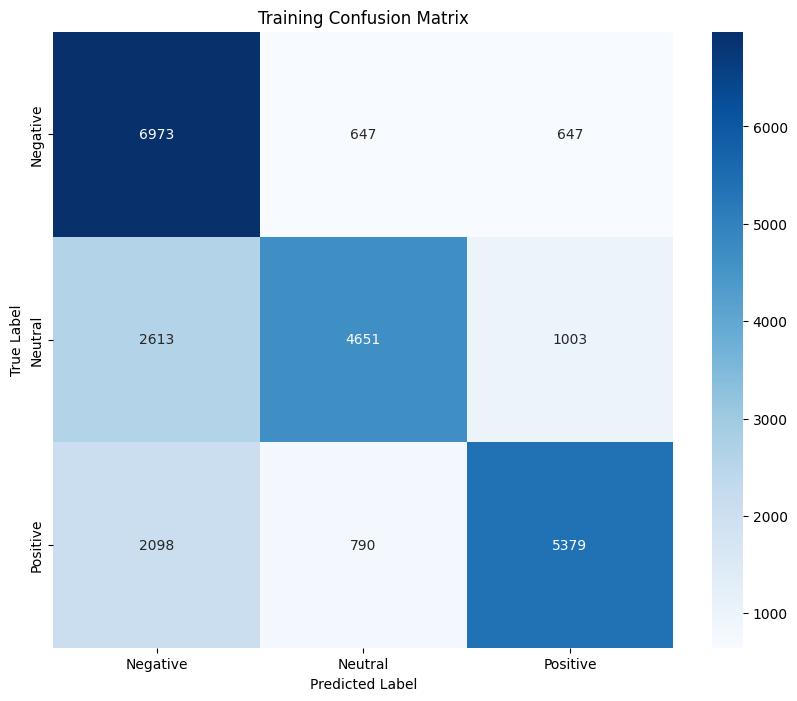

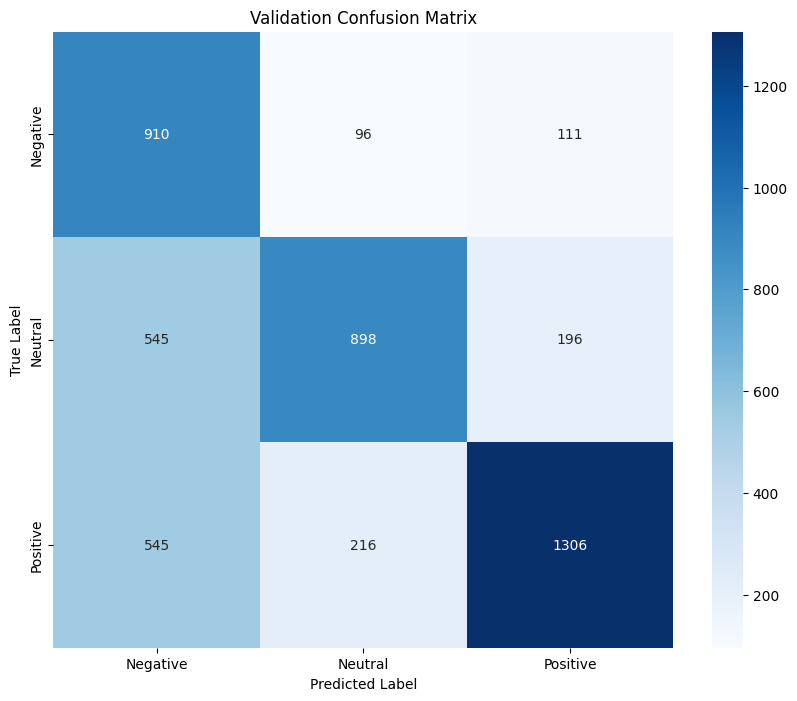

Epoch 2/10
Train loss: 0.2480
Training Accuracy: 0.8000
Validation Accuracy: 0.7516
Training per-class accuracy: {'negative': 0.8033143824845772, 'neutral': 0.8636748518204911, 'positive': 0.7329139954034112}
Validation per-class accuracy: {'negative': 0.738585496866607, 'neutral': 0.8194020744356315, 'positive': 0.7048863086598935}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.80      0.80      8267
     neutral       0.73      0.86      0.79      8267
    positive       0.89      0.73      0.80      8267

    accuracy                           0.80     24801
   macro avg       0.81      0.80      0.80     24801
weighted avg       0.81      0.80      0.80     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.74      0.69      1117
     neutral       0.70      0.82      0.76      1639
    positive       0.89      0.70      0.79      2067



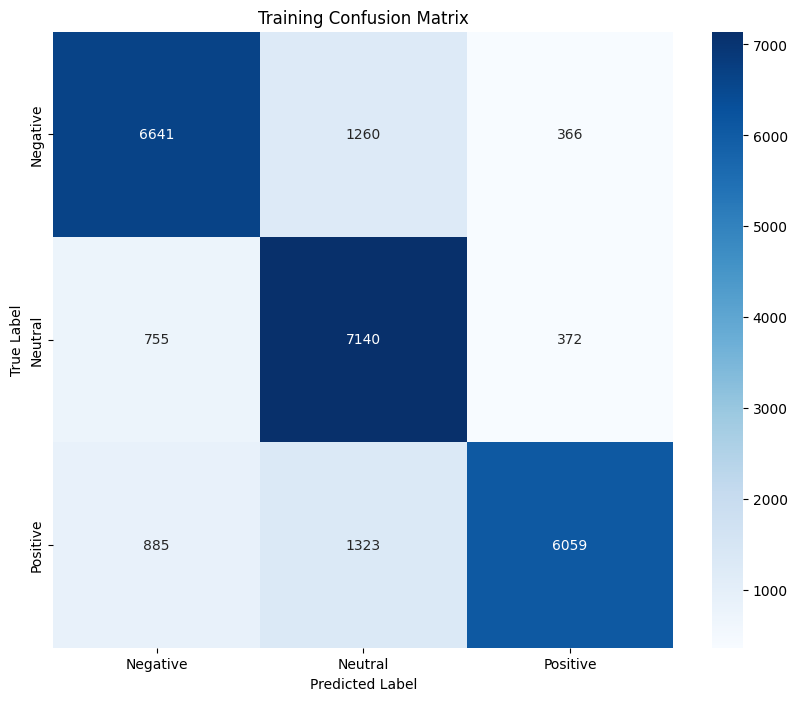

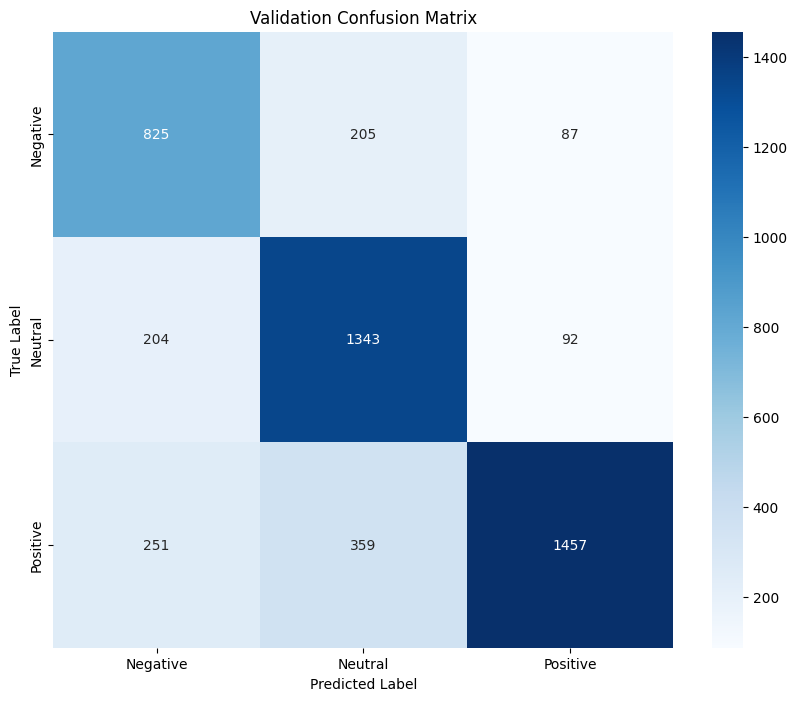

Epoch 3/10
Train loss: 0.1912
Training Accuracy: 0.8628
Validation Accuracy: 0.8010
Training per-class accuracy: {'negative': 0.8571428571428571, 'neutral': 0.8379097617031571, 'positive': 0.8934317164630459}
Validation per-class accuracy: {'negative': 0.7502238137869293, 'neutral': 0.7681513117754728, 'positive': 0.8543783260764393}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      8267
     neutral       0.87      0.84      0.86      8267
    positive       0.84      0.89      0.86      8267

    accuracy                           0.86     24801
   macro avg       0.86      0.86      0.86     24801
weighted avg       0.86      0.86      0.86     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.75      0.74      1117
     neutral       0.81      0.77      0.79      1639
    positive       0.83      0.85      0.84      2067


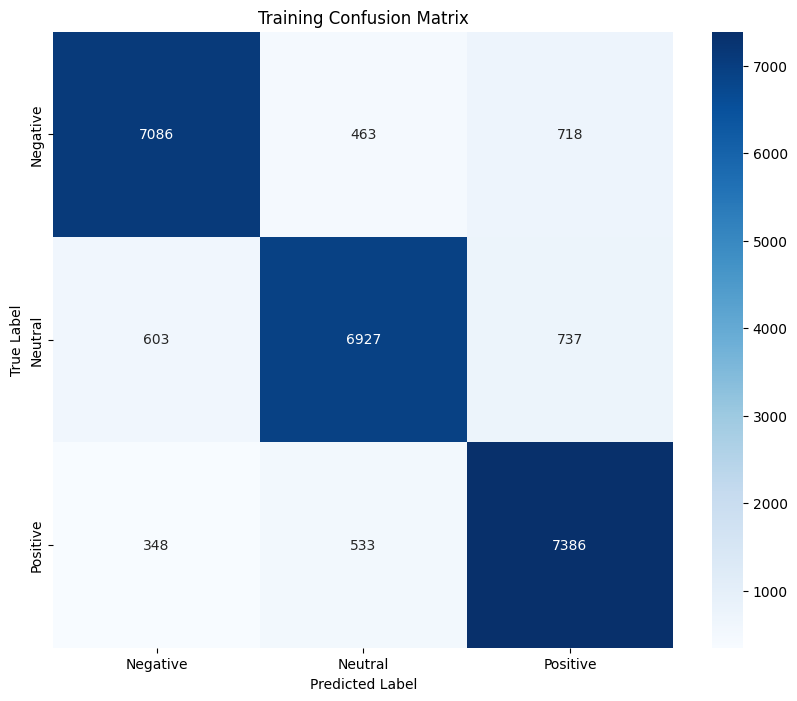

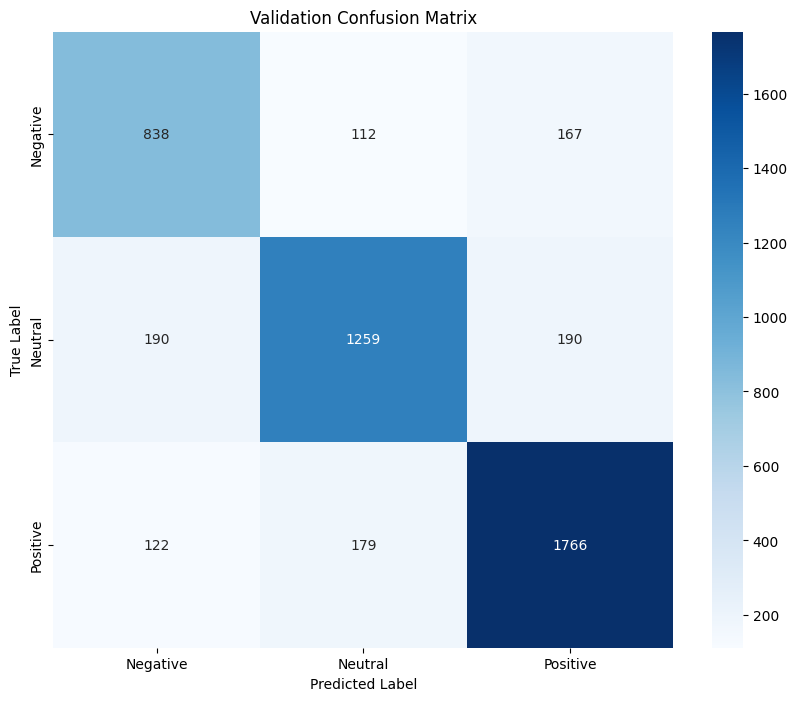

Epoch 4/10
Train loss: 0.1543
Training Accuracy: 0.8970
Validation Accuracy: 0.8066
Training per-class accuracy: {'negative': 0.9158098463771622, 'neutral': 0.8589573001088666, 'positive': 0.9162936978347648}
Validation per-class accuracy: {'negative': 0.7761862130707251, 'neutral': 0.7528981086028066, 'positive': 0.8655055636187712}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.92      0.91      8267
     neutral       0.92      0.86      0.89      8267
    positive       0.87      0.92      0.89      8267

    accuracy                           0.90     24801
   macro avg       0.90      0.90      0.90     24801
weighted avg       0.90      0.90      0.90     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.78      0.75      1117
     neutral       0.84      0.75      0.79      1639
    positive       0.83      0.87      0.85      2067


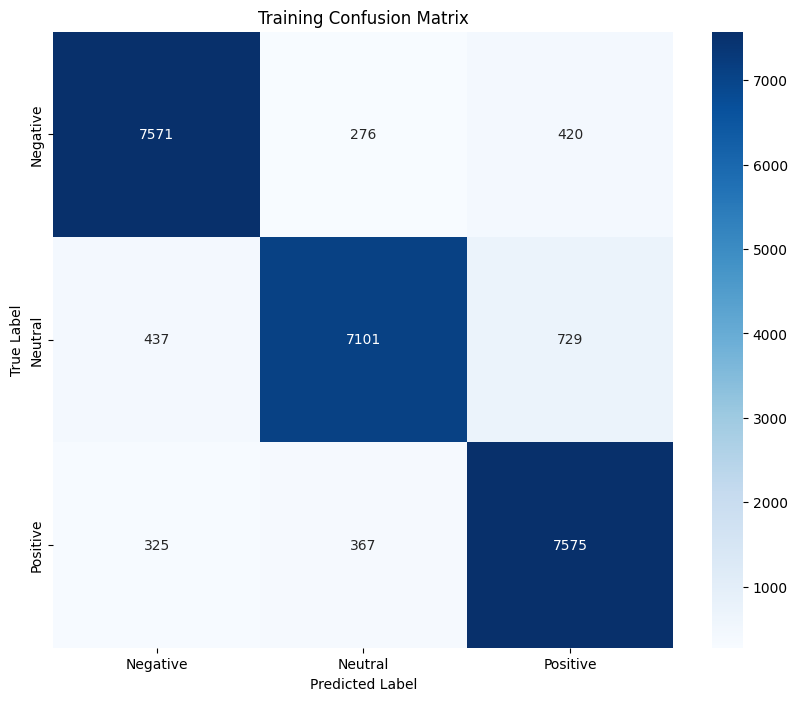

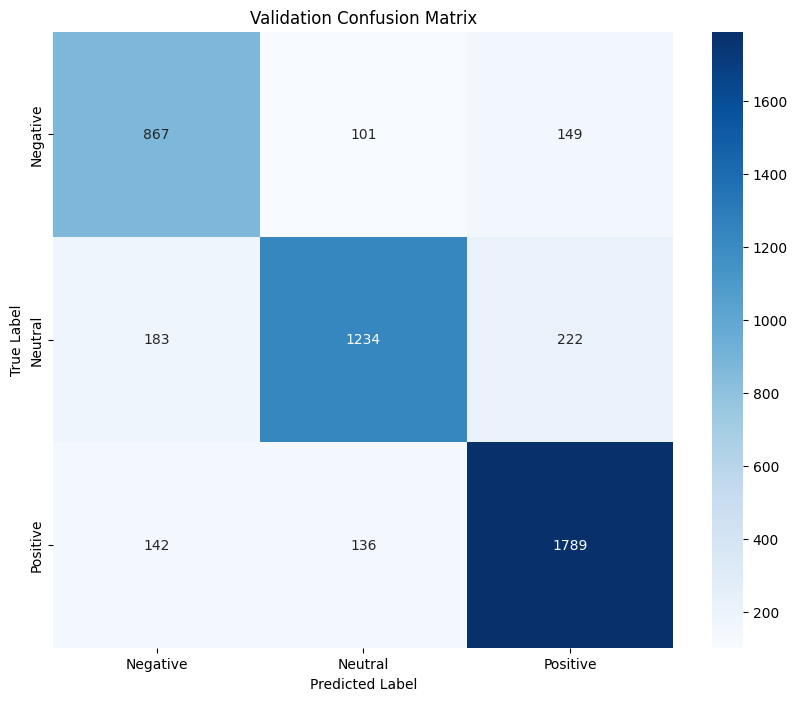

Epoch 5/10
Train loss: 0.1202
Training Accuracy: 0.9103
Validation Accuracy: 0.7885
Training per-class accuracy: {'negative': 0.9587516632393855, 'neutral': 0.8296842869239144, 'positive': 0.9424216765453006}
Validation per-class accuracy: {'negative': 0.7887197851387645, 'neutral': 0.6833435021354485, 'positive': 0.8717948717948718}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.96      0.93      8267
     neutral       0.96      0.83      0.89      8267
    positive       0.88      0.94      0.91      8267

    accuracy                           0.91     24801
   macro avg       0.91      0.91      0.91     24801
weighted avg       0.91      0.91      0.91     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.79      0.73      1117
     neutral       0.86      0.68      0.76      1639
    positive       0.81      0.87      0.84      2067


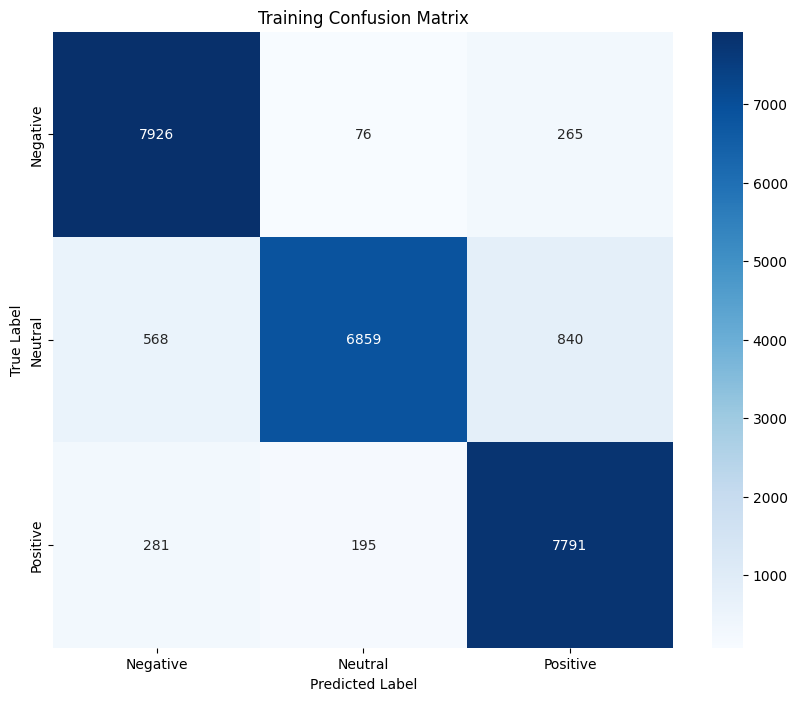

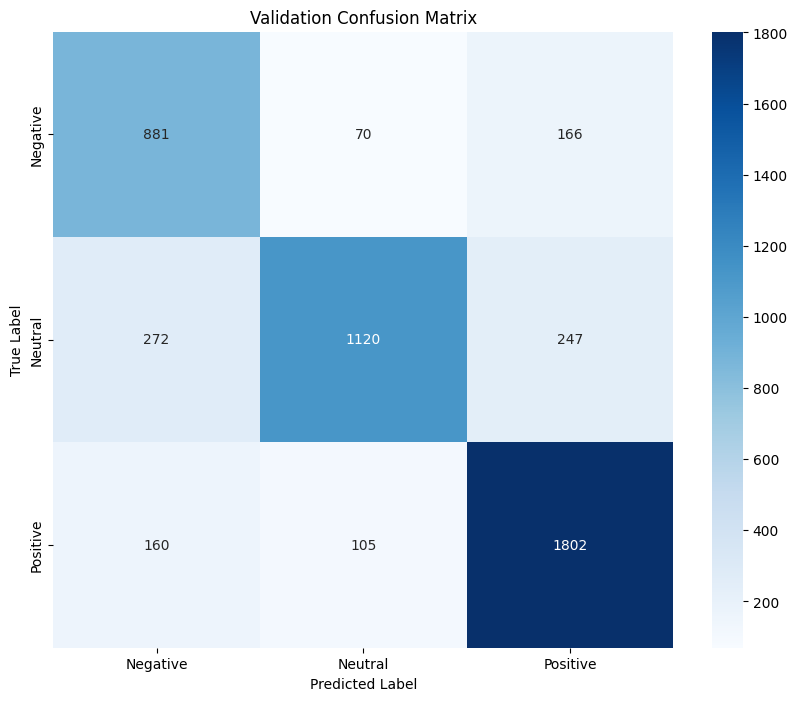

Epoch 6/10
Train loss: 0.0943
Training Accuracy: 0.9550
Validation Accuracy: 0.8074
Training per-class accuracy: {'negative': 0.9635901778154107, 'neutral': 0.9476230797145276, 'positive': 0.9537921857989597}
Validation per-class accuracy: {'negative': 0.7573858549686661, 'neutral': 0.7760829774252593, 'positive': 0.8592162554426706}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96      8267
     neutral       0.96      0.95      0.95      8267
    positive       0.95      0.95      0.95      8267

    accuracy                           0.96     24801
   macro avg       0.96      0.96      0.95     24801
weighted avg       0.96      0.96      0.95     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.76      0.75      1117
     neutral       0.81      0.78      0.79      1639
    positive       0.84      0.86      0.85      2067


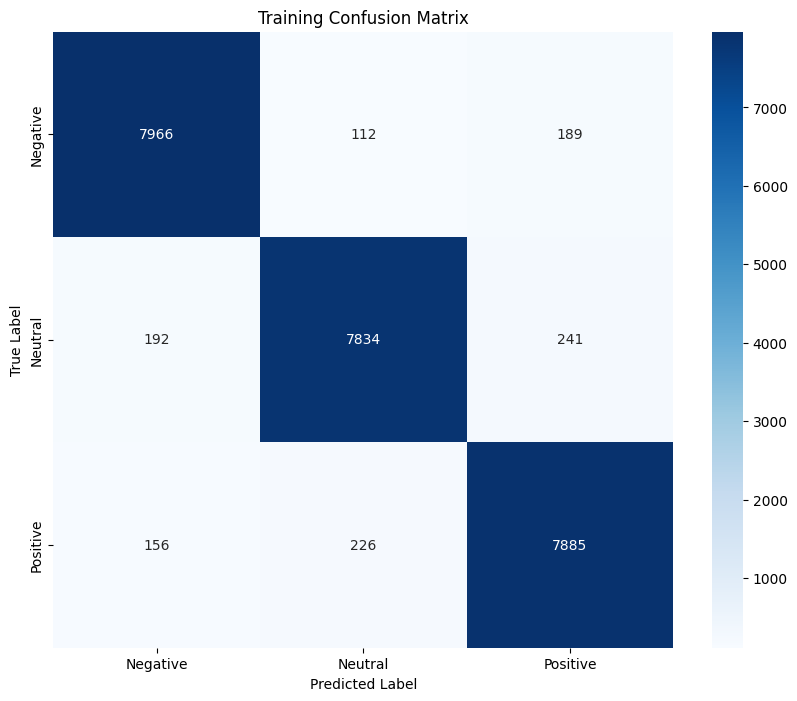

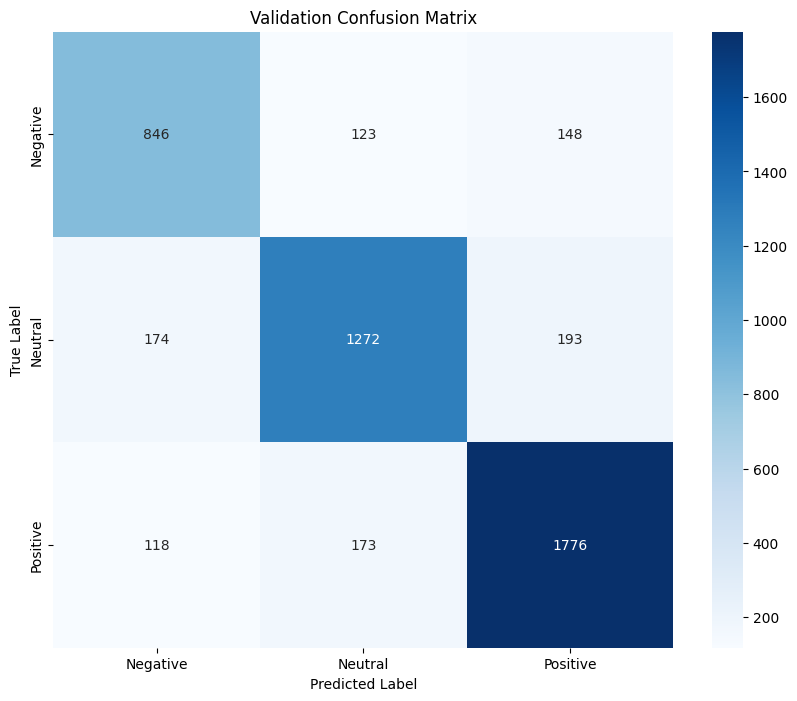

Epoch 7/10
Train loss: 0.0770
Training Accuracy: 0.9666
Validation Accuracy: 0.8155
Training per-class accuracy: {'negative': 0.9744768356114673, 'neutral': 0.9652836579170194, 'positive': 0.9600822547477924}
Validation per-class accuracy: {'negative': 0.7448522829006267, 'neutral': 0.8017083587553386, 'positive': 0.8645379777455249}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.97      0.97      8267
     neutral       0.96      0.97      0.96      8267
    positive       0.96      0.96      0.96      8267

    accuracy                           0.97     24801
   macro avg       0.97      0.97      0.97     24801
weighted avg       0.97      0.97      0.97     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.74      0.76      1117
     neutral       0.81      0.80      0.81      1639
    positive       0.84      0.86      0.85      2067


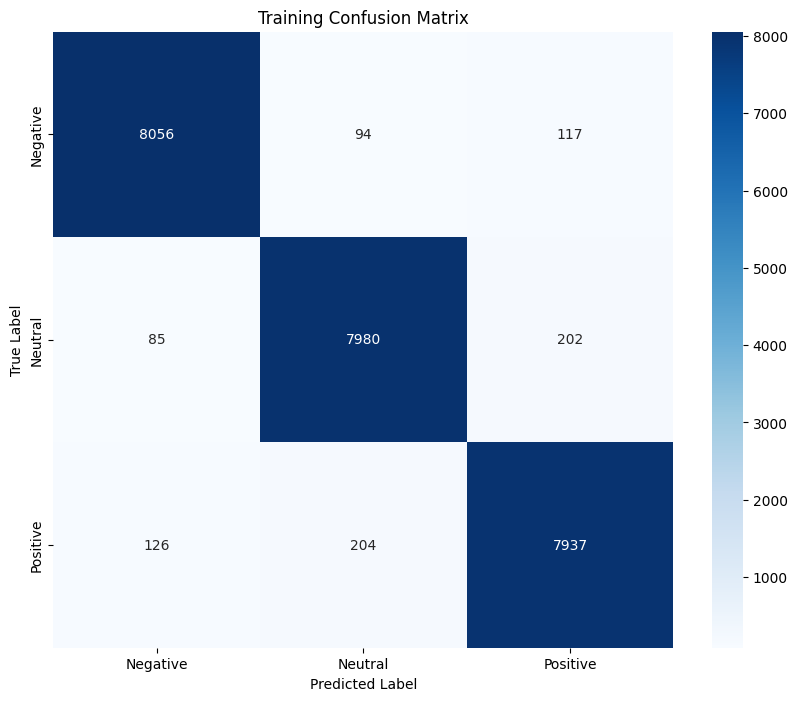

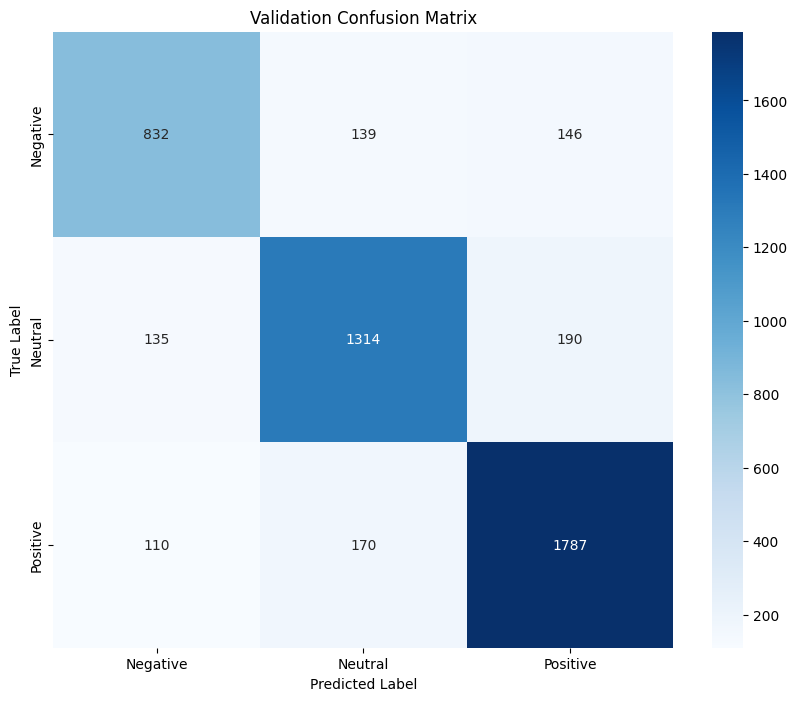

Epoch 8/10
Train loss: 0.0606
Training Accuracy: 0.9725
Validation Accuracy: 0.8144
Training per-class accuracy: {'negative': 0.9834280875771139, 'neutral': 0.9715737268658522, 'positive': 0.9623805491714044}
Validation per-class accuracy: {'negative': 0.7627573858549687, 'neutral': 0.7956070774862721, 'positive': 0.8572810836961781}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.98      0.98      8267
     neutral       0.97      0.97      0.97      8267
    positive       0.97      0.96      0.97      8267

    accuracy                           0.97     24801
   macro avg       0.97      0.97      0.97     24801
weighted avg       0.97      0.97      0.97     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.76      0.75      1117
     neutral       0.82      0.80      0.81      1639
    positive       0.85      0.86      0.86      2067


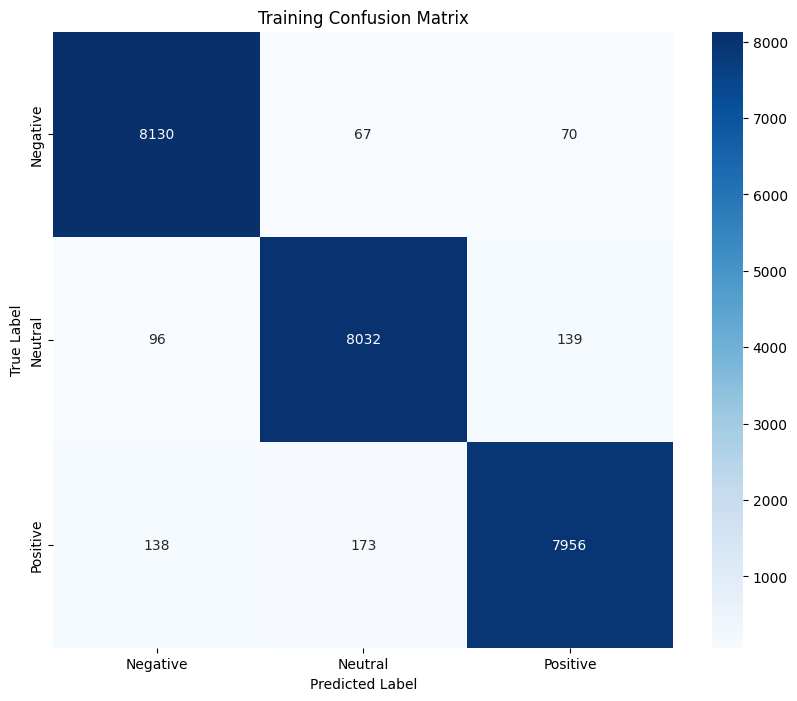

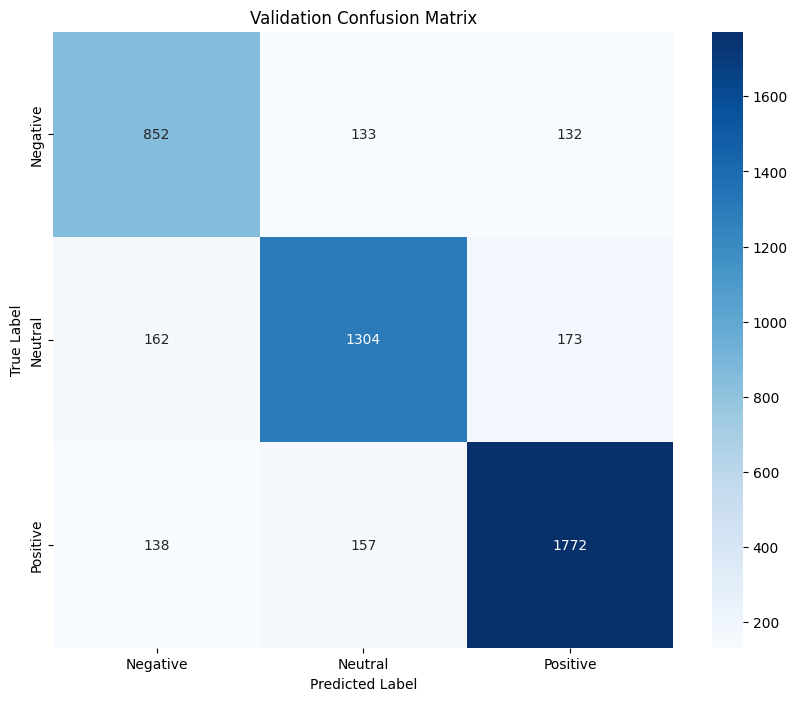

Epoch 9/10
Train loss: 0.0526
Training Accuracy: 0.9767
Validation Accuracy: 0.8126
Training per-class accuracy: {'negative': 0.9848796419499214, 'neutral': 0.9779847586790855, 'positive': 0.9673400266118302}
Validation per-class accuracy: {'negative': 0.7538048343777977, 'neutral': 0.7986577181208053, 'positive': 0.8553459119496856}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.98      0.98      0.98      8267
     neutral       0.98      0.98      0.98      8267
    positive       0.98      0.97      0.97      8267

    accuracy                           0.98     24801
   macro avg       0.98      0.98      0.98     24801
weighted avg       0.98      0.98      0.98     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.75      0.75      1117
     neutral       0.81      0.80      0.80      1639
    positive       0.85      0.86      0.85      2067


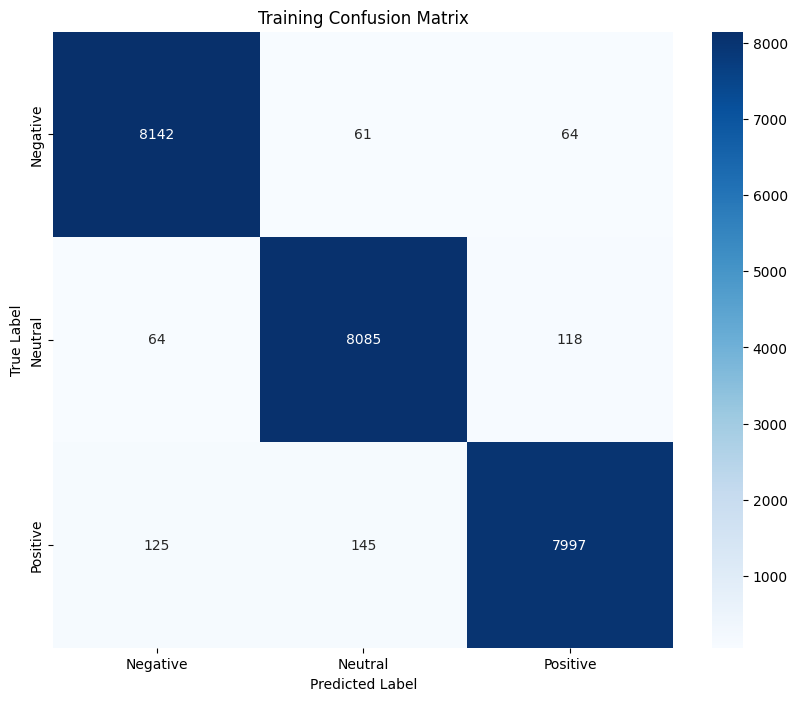

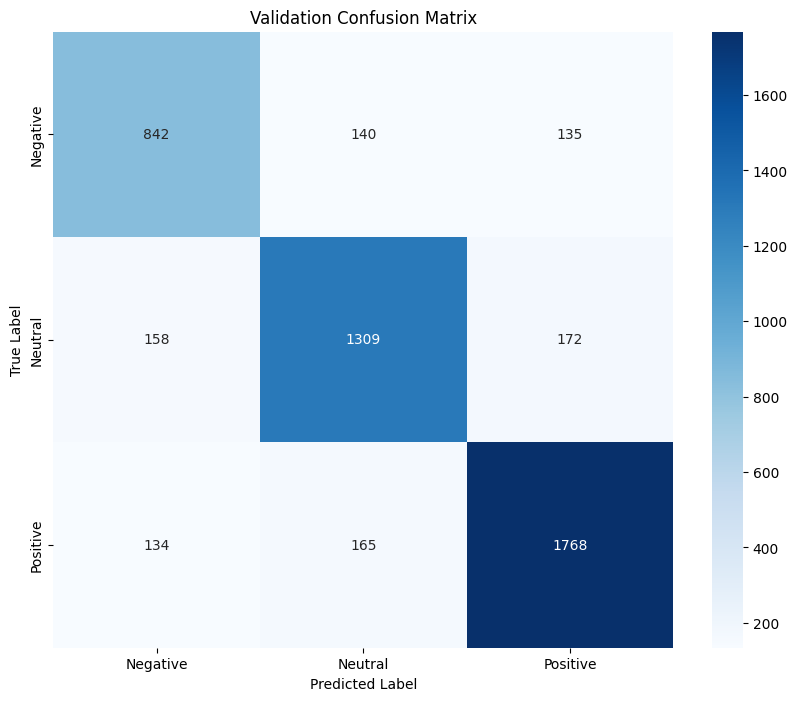

Epoch 10/10
Train loss: 0.0491
Training Accuracy: 0.9768
Validation Accuracy: 0.8107
Training per-class accuracy: {'negative': 0.9852425305431233, 'neutral': 0.9761703157130761, 'positive': 0.9689125438490384}
Validation per-class accuracy: {'negative': 0.7573858549686661, 'neutral': 0.7907260524710189, 'positive': 0.8553459119496856}
Training Classification Report:
              precision    recall  f1-score   support

    negative       0.98      0.99      0.98      8267
     neutral       0.98      0.98      0.98      8267
    positive       0.98      0.97      0.97      8267

    accuracy                           0.98     24801
   macro avg       0.98      0.98      0.98     24801
weighted avg       0.98      0.98      0.98     24801

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.76      0.75      1117
     neutral       0.81      0.79      0.80      1639
    positive       0.85      0.86      0.85      2067

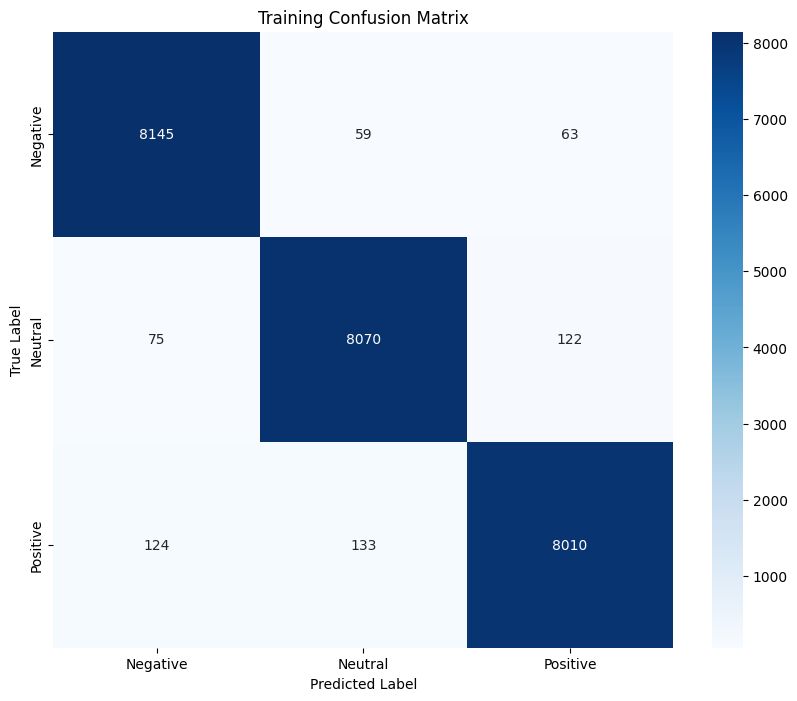

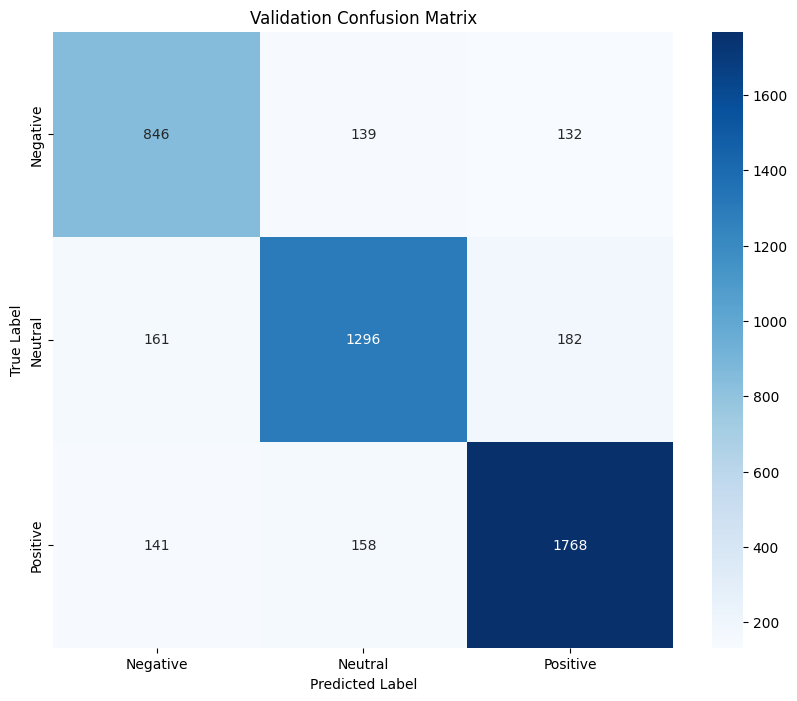

Model architecture diagram saved as 'bart_encoder_architecture.png'.


In [5]:
import torch

# 8. Training and evaluation loop
best_model_saved = False

# Define the list of all possible class labels for consistent reporting
ALL_CLASS_LABELS = ["negative", "neutral", "positive"]

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    print(f"Train loss: {train_loss:.4f}")

    model.eval()
    train_preds_raw, train_labels_decoded = [], []
    val_preds_raw, val_labels_decoded = [], []

    with torch.no_grad():
        # Evaluate on training set
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=10)
            train_preds_raw.extend([tokenizer.decode(g, skip_special_tokens=True) for g in outputs])
            train_labels_decoded.extend([tokenizer.decode(l, skip_special_tokens=True) for l in batch['labels']])

        # Evaluate on validation set
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=10)
            val_preds_raw.extend([tokenizer.decode(g, skip_special_tokens=True) for g in outputs])
            val_labels_decoded.extend([tokenizer.decode(l, skip_special_tokens=True) for l in batch['labels']])

    # Normalize predictions and true labels to all defined classes
    train_preds = [normalize_prediction(pred) for pred in train_preds_raw]
    val_preds = [normalize_prediction(pred) for pred in val_preds_raw]
    train_labels_norm = [normalize_prediction(label) for label in train_labels_decoded]
    val_labels_norm = [normalize_prediction(label) for label in val_labels_decoded]

    train_accuracy = calculate_accuracy(train_labels_norm, train_preds)
    val_accuracy = calculate_accuracy(val_labels_norm, val_preds)
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

    train_class_acc = per_class_accuracy(train_labels_norm, train_preds)
    val_class_acc = per_class_accuracy(val_labels_norm, val_preds)
    print("Training per-class accuracy:", train_class_acc)
    print("Validation per-class accuracy:", val_class_acc)

    print("Training Classification Report:")
    print(classification_report(train_labels_norm, train_preds, labels=ALL_CLASS_LABELS))
    print("Validation Classification Report:")
    print(classification_report(val_labels_norm, val_preds, labels=ALL_CLASS_LABELS))

    plot_confusion_matrix(train_labels_norm, train_preds, title="Training Confusion Matrix")
    plot_confusion_matrix(val_labels_norm, val_preds, title="Validation Confusion Matrix")
    # REMOVED: plot_roc_curve call as it's primarily for binary classification

    if train_accuracy >= 0.97 and not best_model_saved:
        torch.save(model.state_dict(), "/content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/ML model/sentiment_model.pt")
        best_model_saved = True
        print("Model with 97% training accuracy saved!")

# 9. Plot the model architecture using torchviz
def plot_model_architecture(model, tokenizer, device):
    dummy_texts = ["classify: This is a dummy text.", "classify: Another example."]
    dummy_inputs = tokenizer(dummy_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
    input_ids = dummy_inputs['input_ids'].to(device)
    attention_mask = dummy_inputs['attention_mask'].to(device)

    # For BART, we plot the encoder part
    outputs = model.model.encoder(input_ids=input_ids, attention_mask=attention_mask)
    dot = make_dot(outputs.last_hidden_state, params=dict(model.named_parameters()))
    dot.format = "png"
    dot.render("bart_encoder_architecture", view=False) # view=False to prevent opening a new window
    print("Model architecture diagram saved as 'bart_encoder_architecture.png'.")

plot_model_architecture(model, tokenizer, device)

In [6]:
import torch

# Save the current state of the model immediately
save_path = "/content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/ML model/sentiment_model_current_state.pt"
torch.save(model.state_dict(), save_path)
print(f"Current model state saved to: {save_path}")

Current model state saved to: /content/gdrive/MyDrive/Classroom/AI 6c 4(Lab)/ML model/sentiment_model_current_state.pt
